# **Image Assignment ADNE: ML**
#### By Guillermo Velasco, David Fernández-Madera y Rafael de Bloteau

Classical machine learning models generally struggle with raw image data because of its high dimensionality and spatial structure, but some can still perform reasonably well if features are properly extracted beforehand (e.g., using SIFT, HOG, or PCA). Among classical ML models, the ones that tend to perform better for image classification are:

### Support Vector Machines (SVM)
- Performs well with high-dimensional data.
- Works well when combined with feature extraction.
- Good for binary and multi-class classification.

### k-Nearest Neighbors (k-NN)
- Simple and effective for small datasets.
- Sensitive to dimensionality, but can perform decently with reduced features.

### Random Forests / Decision Trees
- Handle nonlinear relationships well.
- Robust to noise, but might not generalize well on complex image data unless features are well-engineered.


### Imports

In [ ]:
import pandas as pd
import numpy as np
import cv2
from datasets import load_dataset
import io
import sys
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.utils import shuffle


c:\Users\guill\miniconda3\envs\torch-gpu-fresh2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load dataset

In [ ]:
# Carga el dataset desde Hugging Face
dataset = load_dataset("nks9/NKS_EYE_DISEASE_CLASSIFICATION", split="train")

# Convierte el dataset a un DataFrame de pandas
df = dataset.to_pandas()

# Muestra las primeras filas del DataFrame
print(df.head())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/567 [00:00<?, ?B/s]

train-00000-of-00002.parquet:   0%|          | 0.00/346M [00:00<?, ?B/s]

train-00001-of-00002.parquet:   0%|          | 0.00/360M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/66.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3795 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/422 [00:00<?, ? examples/s]

                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      1
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0


In [ ]:
# Optional: label mapping (custom names)
label_map = {
    0: "cataract",
    1: "diabetic_retinopathy",
    2: "glaucoma",
    3: "normal"
    # Add more if needed
}

# Shuffle the dataset
df = shuffle(df, random_state=42)

# Get all unique labels
unique_labels = df['label'].unique()

# Loop through each class
for label in unique_labels:
    label_str = label_map[label] if label in label_map else str(label)

    # Subset DataFrame for this class
    class_df = df[df['label'] == label]

    # Split: first 200 for validation, rest for training
    val_df = class_df.iloc[:200]
    train_df = class_df.iloc[200:]

    # Create directories
    os.makedirs(f"train/{label_str}", exist_ok=True)
    os.makedirs(f"val/{label_str}", exist_ok=True)

    # Save training images
    for idx, row in train_df.iterrows():
        image = Image.open(io.BytesIO(row['image']['bytes']))
        if image.mode != "RGB":
            image = image.convert("RGB")
        filename = f"image_{idx}.jpg"
        image.save(os.path.join(f"train/{label_str}", filename))

    # Save validation images
    for idx, row in val_df.iterrows():
        image = Image.open(io.BytesIO(row['image']['bytes']))
        if image.mode != "RGB":
            image = image.convert("RGB")
        filename = f"image_{idx}.jpg"
        image.save(os.path.join(f"val/{label_str}", filename))


In [ ]:
train_dir = "C:\\Users\\guill\\Documents\\master\\ImagenAdne\\PracticaImagen\\dataset\\train"
val_dir   = "C:\\Users\\guill\\Documents\\master\\ImagenAdne\\PracticaImagen\\dataset\\val"


### Feature extraction

Instead of training a Convolutional Neural Network (CNN) from scratch, which would require a vast amount of data and computational power, we use a pretrained model like **ResNet50**, which has already been trained on a large and diverse dataset like **ImageNet**. ImageNet consists of millions of images across thousands of categories, allowing the model to learn and recognize a wide variety of features such as textures, shapes, colors, and objects.

The idea here is to **reuse** the knowledge learned by ResNet50 for our specific task by using it as a feature extractor. We remove the final classification layer of the model (i.e., the fully connected layer used for classification) and only keep the convolutional layers, which contain high-level, general-purpose features that can be applied to other tasks.

Here's why this is beneficial:

- **Pretrained Knowledge**: The pretrained model has learned useful low-level and high-level features like edges, textures, and complex patterns. By removing the final layer, we "borrow" these learned features without needing to train the entire model.
- **Feature Extraction**: The model produces high-dimensional feature vectors that capture important aspects of the image. These vectors can be used as input to classical machine learning models, such as SVM, KNN, or Random Forest, for classification or clustering tasks.
- **Data Efficiency**: Instead of needing a massive amount of labeled data to train a CNN, we can train a simpler classical ML model on the extracted features, significantly reducing the need for large datasets.
- **Time and Resource Savings**: Using a pretrained model saves computational resources because we do not need to perform time-consuming training from scratch. We can focus on optimizing the model for our specific task by fine-tuning only the classifier or using the extracted features directly.

Thus, by utilizing **transfer learning**, we can benefit from a powerful, pretrained neural network and use its features to enhance the performance of simpler, less computationally expensive machine learning models.

In summary, the approach of using pretrained CNN models for feature extraction is an efficient and effective method for image classification tasks, especially when data and compute resources are limited.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import numpy as np

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Load pre-trained ResNet50 model, remove the final classification layer
resnet50 = models.resnet50(pretrained=True)
resnet50 = nn.Sequential(*list(resnet50.children())[:-1])  # Remove last FC layer
resnet50.eval()
resnet50.to(device)

# Transformation (same as preprocess_input for ResNet50 in Keras)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                         std=[0.229, 0.224, 0.225])   # ImageNet stds
])

# Function to extract features from a single image
def extract_features(img_path):
    img = Image.open(img_path).convert('RGB')  # Ensure 3 channels
    img_tensor = preprocess(img).unsqueeze(0).to(device)  # Add batch dimension
    with torch.no_grad():
        features = resnet50(img_tensor)
    return features.cpu().numpy().flatten()  # Return as 1D NumPy array

# Example usage
features = []
labels = []

"""
for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)
    image_count = 0
    for fname in os.listdir(class_dir):
        if image_count >= 10:
            break
        fpath = os.path.join(class_dir, fname)
        try:
            feat = extract_features(fpath)
            features.append(feat)
            labels.append(label)
            image_count += 1
        except Exception as e:
            print(f"Error with {fpath}: {e}")

"""

for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        try:
            feat = extract_features(fpath)
            features.append(feat)
            labels.append(label)
        except Exception as e:
            print(f"Error processing {fpath}: {e}")



# Convert to numpy arrays
X = np.array(features)
y = np.array(labels)


cuda


c:\Users\guill\miniconda3\envs\torch-gpu-fresh2\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\guill\miniconda3\envs\torch-gpu-fresh2\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


After having completed the feature extraction, we will start with the classical ML models.

### SVM

We have chosen a grid formed by different values of the following hyperparameters:

- **C**: Controls the trade-off between a smooth decision boundary and correctly classifying training points.

- **gamma**: Defines the influence of a single training example (used in `'rbf'` and `'poly'` kernels).

- **kernel**: Type of kernel function to be used by the SVM. Options include:
  
  1. `'linear'`: Linear hyperplane  
  2. `'rbf'`: Radial Basis Function (nonlinear, Gaussian)  
  3. `'poly'`: Polynomial kernel  


Additionally, cross-validation (`cv=5`) has been applied in order to better **generalize the model's performance** and reduce the risk of overfitting.

Cross-validation works by splitting the training data into 5 folds. The model is trained on 4 of the folds and validated on the remaining one. This process is repeated 5 times, each time using a different fold as the validation set. The final performance is averaged across all folds to select the best combination of hyperparameters.


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.8981636060100167
                      precision    recall  f1-score   support

            cataract       0.94      0.93      0.94       147
diabetic_retinopathy       0.98      0.99      0.98       160
            glaucoma       0.81      0.81      0.81       140
              normal       0.85      0.85      0.85       152

            accuracy                           0.90       599
           macro avg       0.90      0.90      0.90       599
        weighted avg       0.90      0.90      0.90       599



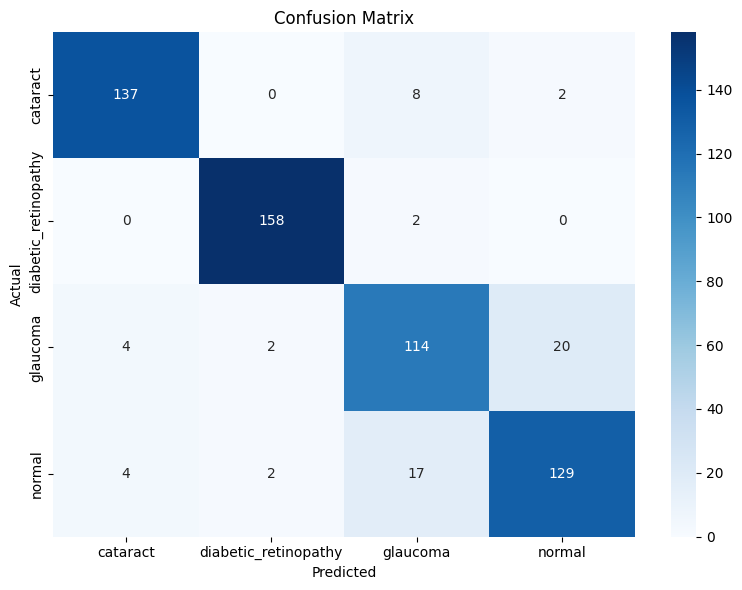

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y must already exist from previous steps

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'linear']
}

# Grid search with cross-validation
grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Train the model
grid.fit(X_train_scaled, y_train)

# Best model
best_svm = grid.best_estimator_

# Predictions
y_pred = best_svm.predict(X_test_scaled)

# Evaluation
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### Model Evaluation Results

After performing a grid search with **5-fold cross-validation** and training the model with the best hyperparameters, we achieved the following results:

- **Best Parameters**: `{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}`  
  These hyperparameters were found to give the best performance during cross-validation.
  - `C=10`: A larger value of `C` indicates a smaller penalty for misclassifications, allowing the model to focus on fitting the training data more accurately.
  - `gamma='scale'`: This automatically scales `gamma` to 1 / (n_features * X.var()), which tends to work well in practice for most datasets.
  - `kernel='rbf'`: The Radial Basis Function (RBF) kernel was selected, which is useful for capturing non-linear decision boundaries.

- **Accuracy**: `0.898` (approximately 90% accuracy)  
  This indicates that the model correctly classified around 90% of the test samples.

### Detailed Classification Metrics

We also report precision, recall, and F1-score for each class:

- **Cataract**:
  - Precision: `0.94` (94% of the predicted cataract cases were actually cataract).
  - Recall: `0.93` (93% of the actual cataract cases were correctly predicted).
  - F1-Score: `0.94` (harmonic mean of precision and recall, giving a balanced measure of performance).
  
- **Diabetic Retinopathy**:
  - Precision: `0.98` (98% of the predicted diabetic retinopathy cases were actually diabetic retinopathy).
  - Recall: `0.99` (99% of the actual diabetic retinopathy cases were correctly predicted).
  - F1-Score: `0.98` (high F1-score indicating good performance).

- **Glaucoma**:
  - Precision: `0.81` (81% of the predicted glaucoma cases were actually glaucoma).
  - Recall: `0.81` (81% of the actual glaucoma cases were correctly predicted).
  - F1-Score: `0.81` (average performance, indicating some room for improvement in predicting this class).

- **Normal**:
  - Precision: `0.85` (85% of the predicted normal cases were actually normal).
  - Recall: `0.85` (85% of the actual normal cases were correctly predicted).
  - F1-Score: `0.85` (balanced performance for the normal class).

### Macro and Weighted Average

- **Macro Average**:  
  - Precision: `0.90`  
  - Recall: `0.90`  
  - F1-Score: `0.90`  
  This is the average performance across all classes, treating each class equally. It indicates that the model performs fairly consistently across the different classes.

- **Weighted Average**:  
  - Precision: `0.90`  
  - Recall: `0.90`  
  - F1-Score: `0.90`  
  The weighted average takes into account the support (number of samples) for each class, showing that the model is performing equally well across all classes, with no major imbalance in the prediction quality.

### Confusion Matrix

A confusion matrix has been used to visually assess how well the model is performing across each class. It shows the number of correct and incorrect predictions for each class. The results are really good in general, however, the model has a slight tendency to confuse glaucoma with a normal eye.

### Conclusion

The model performs well overall with a good balance between precision, recall, and F1-score. There is, however, some room for improvement, especially with the **glaucoma** class, where precision and recall are lower compared to other classes.


### KNN

We have chosen a grid formed by different values of the following hyperparameters for the **K-Nearest Neighbors (KNN)** algorithm:

- **n_neighbors**: The number of neighbors to use when making a prediction. Possible values include:
  
  1. `3`: Smallest number of neighbors  
  2. `5`: Default value in KNN  
  3. `7`: Larger number of neighbors  
  4. `9`: Even larger number of neighbors

- **weights**: The method to use for weighting the influence of neighbors during prediction:
  
  1. `'uniform'`: All neighbors have equal influence.  
  2. `'distance'`: Closer neighbors have more influence.

- **metric**: The distance metric used to measure the closeness between points:
  
  1. `'euclidean'`: Standard Euclidean distance, commonly used.  
  2. `'manhattan'`: The sum of the absolute differences between the points.

Additionally, **cross-validation (`cv=5`)** has been applied to help **generalize the model's performance** and reduce overfitting.

Cross-validation works by splitting the dataset into 5 folds. The model is trained on 4 folds and validated on the remaining fold. This process is repeated 5 times, each time using a different fold as the validation set. The final performance is averaged over all folds to find the best hyperparameter combination.

The best KNN model is then selected based on the grid search results. After training, predictions are made on the test set, and various performance metrics (such as accuracy, precision, recall, and F1-score) are reported, along with a **confusion matrix** to visualize how well the model is classifying each class.


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Accuracy: 0.8464106844741235
                      precision    recall  f1-score   support

            cataract       0.89      0.90      0.89       147
diabetic_retinopathy       0.97      0.89      0.93       160
            glaucoma       0.77      0.74      0.75       140
              normal       0.76      0.86      0.80       152

            accuracy                           0.85       599
           macro avg       0.85      0.84      0.84       599
        weighted avg       0.85      0.85      0.85       599



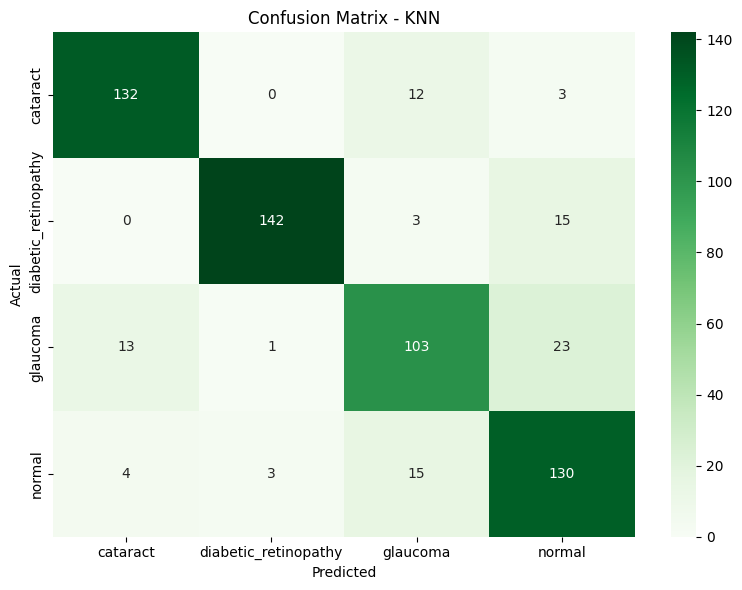

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the hyperparameter grid for KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid search
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Train the model
grid.fit(X_train_scaled, y_train)

# Best KNN model
best_knn = grid.best_estimator_

# Predict
y_pred = best_knn.predict(X_test_scaled)

# Evaluation
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()


### Model Evaluation Results

After performing a grid search with **5-fold cross-validation** and training the KNN model with the best hyperparameters, we obtained the following results:

- **Best Parameters**: `{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}`  
  These hyperparameters were found to provide the best performance during cross-validation.
  - `metric='manhattan'`: This distance metric calculates the sum of the absolute differences between points, suitable for cases where the data has a grid-like structure.
  - `n_neighbors=5`: The model uses the 5 nearest neighbors to make predictions.
  - `weights='distance'`: Neighbors closer to the query point have more influence in the decision, helping the model focus on local patterns.

- **Accuracy**: `0.846` (approximately 85% accuracy)  
  This shows that the model correctly classified about 85% of the test samples.

### Detailed Classification Metrics

We report precision, recall, and F1-score for each class:

- **Cataract**:
  - Precision: `0.89` (89% of the predicted cataract cases were actually cataract).
  - Recall: `0.90` (90% of the actual cataract cases were correctly predicted).
  - F1-Score: `0.89` (well-balanced performance for this class).

- **Diabetic Retinopathy**:
  - Precision: `0.97` (97% of the predicted diabetic retinopathy cases were actually diabetic retinopathy).
  - Recall: `0.89` (89% of the actual diabetic retinopathy cases were correctly predicted).
  - F1-Score: `0.93` (a good balance between precision and recall for this class).

- **Glaucoma**:
  - Precision: `0.77` (77% of the predicted glaucoma cases were actually glaucoma).
  - Recall: `0.74` (74% of the actual glaucoma cases were correctly predicted).
  - F1-Score: `0.75` (modest performance, indicating some room for improvement in predicting this class).

- **Normal**:
  - Precision: `0.76` (76% of the predicted normal cases were actually normal).
  - Recall: `0.86` (86% of the actual normal cases were correctly predicted).
  - F1-Score: `0.80` (balanced performance for this class).

### Macro and Weighted Average

- **Macro Average**:  
  - Precision: `0.85`  
  - Recall: `0.84`  
  - F1-Score: `0.84`  
  The macro average considers each class equally and shows that the KNN model performs fairly well across all classes.

- **Weighted Average**:  
  - Precision: `0.85`  
  - Recall: `0.85`  
  - F1-Score: `0.85`  
  The weighted average adjusts for the number of samples in each class, giving a good indication that the model performs consistently well, especially considering class imbalances.

### Confusion Matrix

A confusion matrix has been used to visually assess how well the model is performing across each class. It shows the number of correct and incorrect predictions for each class. The results are really good in retinopathy and cataract, however, the model is wrong to classify an eye that is actually healthy or has glaucoma.

### Comparison to SVM

- The **SVM model** achieved an accuracy of **0.90**, which is higher than KNN's **0.85**. However, the KNN model has a simpler setup and can perform well with smaller datasets and fewer hyperparameters.
- In terms of **precision and recall**, KNN performed well, but there were some differences compared to SVM:
  - **KNN** performed slightly worse for **diabetic retinopathy** (recall of 0.89 vs. 0.99 in SVM), and **glaucoma** had a notably lower recall (0.74 vs. 0.81 in SVM).
  - **SVM** also had more consistent performance across all classes, whereas KNN showed slightly higher variation, especially in the **glaucoma** and **normal** classes.
  
### Conclusion

While the **SVM model** generally outperforms the **KNN model** in terms of accuracy and consistent class predictions, the KNN model still provides a solid performance with relatively simpler hyperparameters. The trade-off between simplicity and performance can depend on the specific application and dataset.


### Random Forest

After performing a **grid search with 5-fold cross-validation** and training the **Random Forest Classifier**, we obtained the following results:

**Grid Search Hyperparameters**
- **Best Parameters**:
  - `{'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}`
  
These hyperparameters were selected after evaluating all the candidates during cross-validation. Here's what each parameter represents:
- `bootstrap=False`: The model uses the entire dataset for training each tree (as opposed to using random subsets with replacement).
- `max_depth=20`: The maximum depth of each tree is limited to 20, preventing overfitting by reducing model complexity.
- `min_samples_leaf=1`: Each leaf node of the tree can contain a minimum of 1 sample, ensuring no excessive pruning.
- `min_samples_split=5`: Nodes will only split if at least 5 samples are available, which prevents very small splits and overfitting.
- `n_estimators=100`: The number of decision trees in the forest, 100 is a typical number for a balanced performance and computational efficiency.

Additionally, cross-validation (cv=5) has been applied in order to better generalize the model's performance and reduce the risk of overfitting.


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy: 0.8697829716193656
                      precision    recall  f1-score   support

            cataract       0.88      0.91      0.90       147
diabetic_retinopathy       0.99      0.93      0.96       160
            glaucoma       0.77      0.74      0.75       140
              normal       0.82      0.89      0.85       152

            accuracy                           0.87       599
           macro avg       0.87      0.87      0.87       599
        weighted avg       0.87      0.87      0.87       599



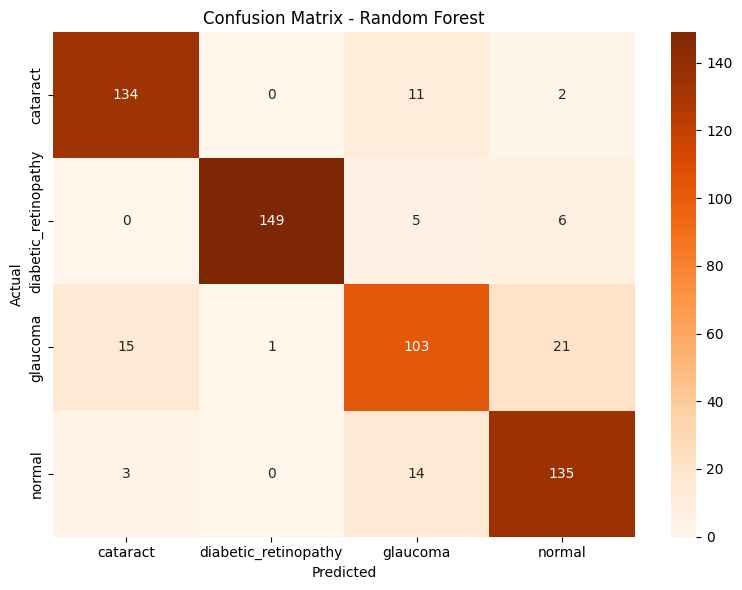

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling (optional for Random Forest, but won’t hurt)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid search parameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Grid search for best Random Forest
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
best_rf = grid.best_estimator_

# Predict
y_pred = best_rf.predict(X_test_scaled)

# Results
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()


Accuracy and Evaluation Metrics

- **Accuracy**: `0.87` (approximately 87% accuracy)
  - This shows that the Random Forest model classified about 87% of the test samples correctly.

#### Detailed Classification Metrics

The performance for each class is summarized as follows:

- **Cataract**:
  - Precision: `0.88` (88% of the predicted cataract cases were actually cataract).
  - Recall: `0.91` (91% of the actual cataract cases were correctly predicted).
  - F1-Score: `0.90` (balanced performance for this class).

- **Diabetic Retinopathy**:
  - Precision: `0.99` (99% of the predicted diabetic retinopathy cases were actually diabetic retinopathy).
  - Recall: `0.93` (93% of the actual diabetic retinopathy cases were correctly predicted).
  - F1-Score: `0.96` (excellent performance with a good balance between precision and recall).

- **Glaucoma**:
  - Precision: `0.77` (77% of the predicted glaucoma cases were actually glaucoma).
  - Recall: `0.74` (74% of the actual glaucoma cases were correctly predicted).
  - F1-Score: `0.75` (modest performance, indicating room for improvement in predicting this class).

- **Normal**:
  - Precision: `0.82` (82% of the predicted normal cases were actually normal).
  - Recall: `0.89` (89% of the actual normal cases were correctly predicted).
  - F1-Score: `0.85` (balanced performance for this class).

#### Macro and Weighted Average

- **Macro Average**:  
  - Precision: `0.87`  
  - Recall: `0.87`  
  - F1-Score: `0.87`  
  The macro average considers each class equally and shows that the Random Forest model performs consistently well across all classes.

- **Weighted Average**:  
  - Precision: `0.87`  
  - Recall: `0.87`  
  - F1-Score: `0.87`  
  The weighted average adjusts for the number of samples in each class, giving an indication that the Random Forest model performs consistently well across imbalanced classes.

#### Confusion Matrix
A confusion matrix is also plotted to visualize the true positives, false positives, true negatives, and false negatives for each class. The results, as in KNN, are quite  good in retinopathy and cataract, however, the model is wrong to classify an eye that is actually healthy or has glaucoma.


### Comparison with KNN and SVM Models

- **Random Forest** (Accuracy: 87%):
  - Random Forest performed relatively well with an accuracy of 87%, which is slightly lower than the **SVM** model (90%) but higher than **KNN** (85%).
  - The performance across individual classes is solid, especially in terms of recall for **cataract** (0.91) and **diabetic retinopathy** (0.93), which are higher compared to **KNN** (0.86 for cataract, 0.89 for diabetic retinopathy) and **SVM** (0.93 for cataract, 0.99 for diabetic retinopathy).
  
- **KNN** (Accuracy: 85%):
  - KNN achieved the lowest accuracy of the three models, but it performed well for **diabetic retinopathy** (precision of 0.97) and **cataract** (precision of 0.89).
  - KNN struggled with **glaucoma** (recall of 0.74) and **normal** (recall of 0.86), similar to Random Forest, but not as well as SVM.

- **SVM** (Accuracy: 90%):
  - The **SVM** model achieved the highest accuracy (90%) overall, particularly excelling in predicting **diabetic retinopathy** with the highest recall (0.99).
  - SVM also performed very well across all classes, especially for **glaucoma** (recall of 0.81) and **normal** (recall of 0.85), which was better than KNN and Random Forest.



### Final conclusions

- **SVM** performed the best overall in terms of accuracy and consistent class predictions, especially for **diabetic retinopathy**.
- **Random Forest** provided a good balance with high recall for **cataract** and **normal** but performed somewhat lower for **glaucoma** compared to SVM.
- **KNN**, although simpler and with fewer parameters to tune, had the lowest accuracy and performed less consistently across all classes.



Although I did not believe that the results obtained with classical ML in an image classification problem would be good, the fact of **performing the feature extraction with DL has allowed us to obtain quite good results, reaching 90% accuracy with SVM.**